# Стекинг: мета-модель поверх базовых прогнозов

Продолжение [10_Base_Models.ipynb](10_Base_Models.ipynb): семь базовых
моделей (CatBoost, LightGBM, RandomForest, ElasticNet, SGD, Nystroem+Ridge,
FAISS KNN) уже обучены с подобранными Optuna гиперпараметрами, их
предсказания сохранены в `data/oof/`.

## Схема стекинга

- **Обучающая выборка мета-модели** — предсказания базовых моделей на
  holdout-cutoff `2026-01-14` (`base_models_holdout.parquet`). Эти
  предсказания честные: все семь базовых моделей на этапе финального рефита
  для holdout обучались на 9 cutoff **до** holdout, сам holdout они не видели.
- **Применение мета-модели** — к предсказаниям базовых моделей на inference
  cutoff `2026-02-13` (`base_models_inference.parquet`), полученным от версий
  базовых моделей, дообученных уже на всех 10 размеченных cutoff.
- Гиперпараметры мета-модели подбираются Optuna на случайном K-fold CV **внутри**
  holdout-таблицы (~230-250 тыс. строк одного snapshot, без временной структуры
  внутри — так что случайный K-fold здесь корректен).

## Импорты и загрузка сохранённых предсказаний

In [1]:
from pathlib import Path
import sys


def _find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "data" / "Prepared_data.parquet").exists() and (path / "notebooks").exists():
            return path
    raise FileNotFoundError("Не найден корень проекта с data/Prepared_data.parquet")


sys.path.insert(0, str(_find_project_root() / "src"))


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold
import lightgbm as lgb

import optuna
from optuna.samplers import TPESampler

from validation import rmsle
from tabular_data import (
    SUBMISSIONS_DIR,
    OOF_DIR,
    HOLDOUT_CUTOFF,
    INFERENCE_CUTOFF,
    load_prepared_data,
    subset_by_cutoffs,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
N_JOBS = 8  # см. N_JOBS в 09_Base_Models.ipynb — явно, а не n_jobs=-1, из-за контейнерных сред
MODEL_NAMES = [
    "catboost", "lightgbm", "random_forest", "elasticnet", "sgd", "nystroem_ridge", "faiss_knn",
]

holdout_table = pd.read_parquet(OOF_DIR / "base_models_holdout.parquet")
inference_table = pd.read_parquet(OOF_DIR / "base_models_inference.parquet")

print("holdout:", holdout_table.shape)
print("inference:", inference_table.shape)
holdout_table.head()

holdout: (250000, 8)
inference: (250000, 7)


,y_true,catboost,lightgbm,random_forest,elasticnet,sgd,nystroem_ridge,faiss_knn
user_id,,,,,,,,
2,0.00000,2.226353,2.102937,2.836693,1.683392,1.276632,1.749334,3.076966
7,486.96535,33.317799,32.323895,33.564666,32.324291,40.430028,36.180180,30.504199
15,0.00000,25.928499,30.435077,34.635024,41.401554,41.570258,49.455441,106.256512
18,276.00910,168.816769,160.036656,161.116562,129.853424,147.312987,203.115799,122.501804
23,0.00000,0.546953,0.547969,0.635395,0.688890,0.161405,0.624059,0.714302


## Корреляция предсказаний базовых моделей

Смотрим в log1p-пространстве (в нём считается метрика) — и на holdout (где
есть истинный target для сравнения по величине ошибки), и на inference
cutoff (реальный тест). Чем ниже корреляция между парой моделей, тем больше
потенциальный выигрыш от их комбинирования: стекинг/блендинг усредняет
некоррелированные ошибки, а не коррелированные.

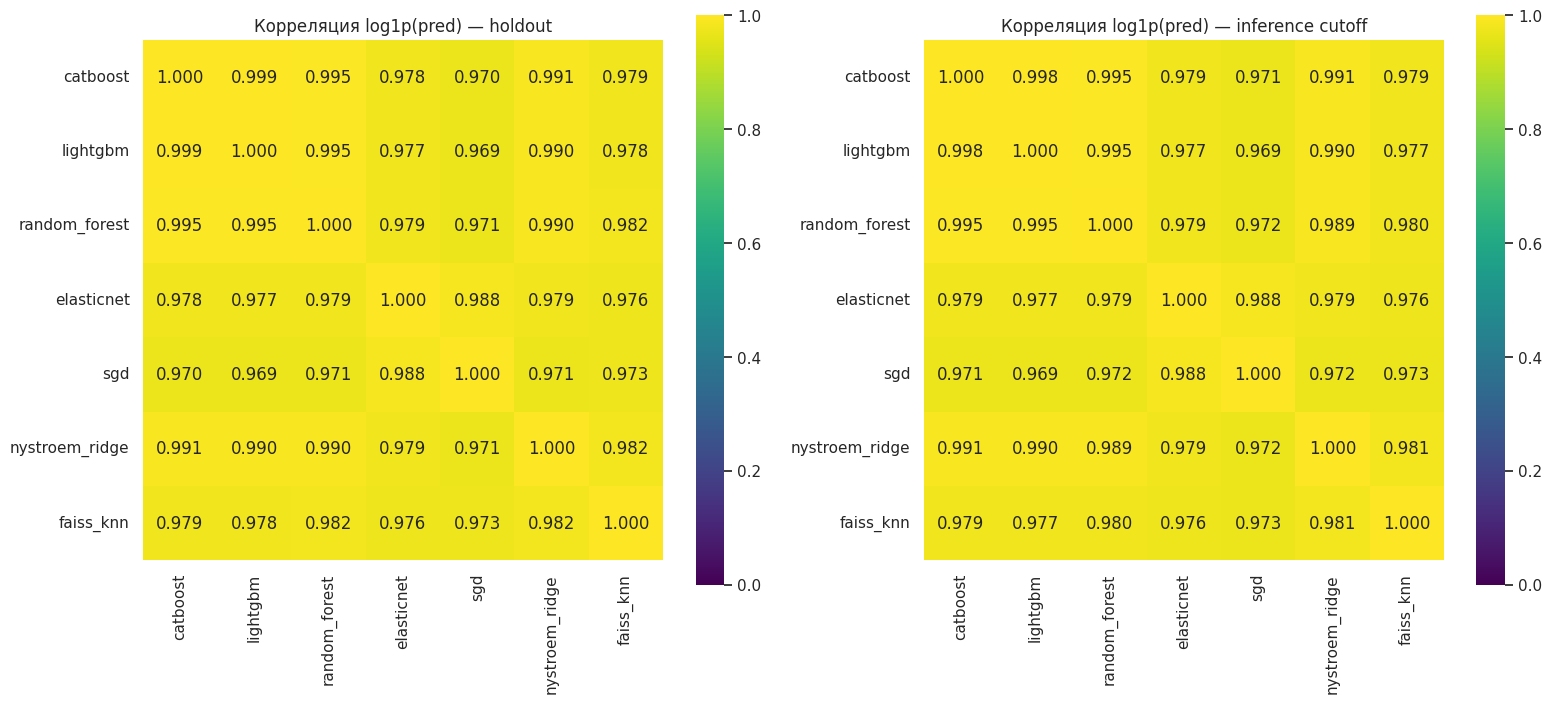

In [3]:
def log_corr(df, columns):
    return np.log1p(df[columns]).corr()


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(log_corr(holdout_table, MODEL_NAMES), annot=True, fmt=".3f", vmin=0, vmax=1, square=True, cmap="viridis", ax=axes[0])
axes[0].set_title("Корреляция log1p(pred) — holdout")

sns.heatmap(log_corr(inference_table, MODEL_NAMES), annot=True, fmt=".3f", vmin=0, vmax=1, square=True, cmap="viridis", ax=axes[1])
axes[1].set_title("Корреляция log1p(pred) — inference cutoff")

plt.tight_layout()
plt.show()


**Анализ.** Все 7 моделей коррелируют между собой на 0.969–0.999 — это очень
высоко, почти без исключений. Даже алгоритмически непохожие модели (FAISS
KNN, SGD, Nystroem+Ridge) коррелируют с CatBoost/LightGBM на 0.97+. Такой
уровень согласия ограничивает потенциал стекинга: модели видят один и тот же
сигнал, и
мета-модели, скорее всего, будет что усреднять/довзвешивать, но не на чем
находить принципиально разные, взаимно компенсирующие ошибки.

In [4]:
base_rmsle = pd.Series({name: rmsle(holdout_table["y_true"], holdout_table[name]) for name in MODEL_NAMES}, name="holdout_rmsle").sort_values()
base_rmsle


lightgbm          1.685417
catboost          1.687667
nystroem_ridge    1.697468
random_forest     1.699183
elasticnet        1.710194
faiss_knn         1.722445
sgd               1.746244
Name: holdout_rmsle, dtype: float64

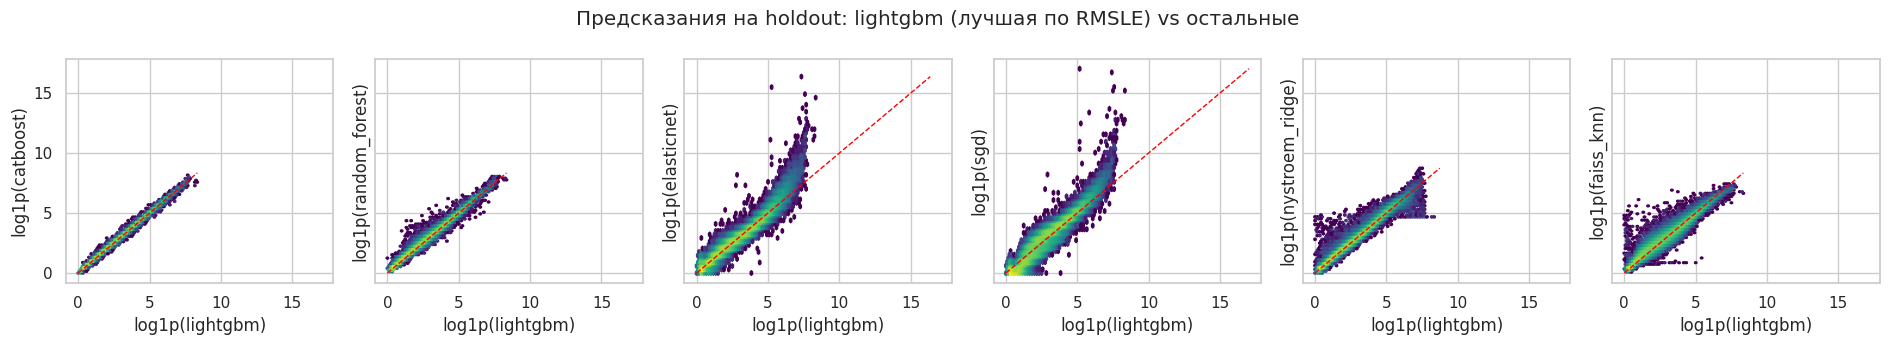

In [5]:
fig, axes = plt.subplots(1, len(MODEL_NAMES) - 1, figsize=(3.2 * (len(MODEL_NAMES) - 1), 3.5), sharex=True, sharey=True)
best_name = base_rmsle.index[0]
others = [m for m in MODEL_NAMES if m != best_name]

for ax, name in zip(axes, others):
    ax.hexbin(np.log1p(holdout_table[best_name]), np.log1p(holdout_table[name]), gridsize=50, bins="log", cmap="viridis")
    lims = [0, max(np.log1p(holdout_table[best_name]).max(), np.log1p(holdout_table[name]).max())]
    ax.plot(lims, lims, color="red", linewidth=1, linestyle="--")
    ax.set_xlabel(f"log1p({best_name})")
    ax.set_ylabel(f"log1p({name})")

plt.suptitle(f"Предсказания на holdout: {best_name} (лучшая по RMSLE) vs остальные")
plt.tight_layout()
plt.show()


**Анализ.** CatBoost и RandomForest ложатся на LightGBM почти точно по
диагонали — три ансабля видят один и тот же сигнал (согласуется с
корреляцией 0.995–0.999 выше). ElasticNet и SGD — единственные, кто заметно
отклоняется.

## Наивные блендинги как бейзлайн для стекинга

In [6]:
def blend_log(df, columns, weights):
    log_pred = sum(w * np.log1p(df[c]) for c, w in zip(columns, weights))
    return np.expm1(log_pred)


uniform_weights = [1 / len(MODEL_NAMES)] * len(MODEL_NAMES)
uniform_pred = blend_log(holdout_table, MODEL_NAMES, uniform_weights)
uniform_rmsle = rmsle(holdout_table["y_true"], uniform_pred)

inverse_rmsle_weights = (1 / base_rmsle.reindex(MODEL_NAMES))
inverse_rmsle_weights = (inverse_rmsle_weights / inverse_rmsle_weights.sum()).values
weighted_pred = blend_log(holdout_table, MODEL_NAMES, inverse_rmsle_weights)
weighted_rmsle = rmsle(holdout_table["y_true"], weighted_pred)

best_single_rmsle = base_rmsle.min()

print(f"лучшая одиночная модель ({base_rmsle.index[0]}): {best_single_rmsle:.5f}")
print(f"uniform blend:                                    {uniform_rmsle:.5f}")
print(f"inverse-RMSLE weighted blend:                      {weighted_rmsle:.5f}")


лучшая одиночная модель (lightgbm): 1.68542
uniform blend:                                    1.69112
inverse-RMSLE weighted blend:                      1.69102


**Анализ.** Оба наивных блендинга (1.691) хуже лучшей одиночной модели
(LightGBM, 1.685) — усреднение в log-пространстве тянет прогноз к слабым
моделям (SGD 1.746, FAISS KNN 1.722), и даже обратные веса по RMSLE не
компенсируют это полностью.

## Подбор мета-модели

Мета-признаки — `log1p` предсказаний семи базовых моделей. Пробуем три
семейства мета-моделей:

- **Ridge** (`l1_ratio=0` в ElasticNet) — простой выпуклый линейный блендинг;
- **ElasticNet** — линейный блендинг с L1-разреженностью (может занулить
  слабые/избыточные базовые модели);
- **неглубокий LightGBM** — на случай нелинейного взаимодействия между
  прогнозами базовых моделей

Подбор — Optuna на 5-fold случайном KFold **внутри** holdout (это не
временной ряд, а один snapshot, поэтому случайный K-fold корректен и не
создаёт утечки будущего).

In [3]:
META_FEATURES = [f"log1p_{name}" for name in MODEL_NAMES]

meta_holdout = pd.DataFrame({f"log1p_{name}": np.log1p(holdout_table[name]) for name in MODEL_NAMES}, index=holdout_table.index)
meta_holdout["y_log"] = np.log1p(holdout_table["y_true"])

meta_inference = pd.DataFrame({f"log1p_{name}": np.log1p(inference_table[name]) for name in MODEL_NAMES}, index=inference_table.index)

KFOLDS = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def meta_cv_rmsle(build_model, df=None, features=None):
    # df/features по умолчанию — meta_holdout/META_FEATURES; параметры нужны, чтобы переиспользовать тот же CV для расширенного набора признаков ниже.
    df = meta_holdout if df is None else df
    features = META_FEATURES if features is None else features
    X = df[features].to_numpy()
    y_log = df["y_log"].to_numpy()
    y_true = np.expm1(y_log)
    scores = []
    for train_idx, val_idx in KFOLDS.split(X):
        model = build_model()
        model.fit(X[train_idx], y_log[train_idx])
        preds = np.clip(np.expm1(model.predict(X[val_idx])), 0, None)
        scores.append(rmsle(y_true[val_idx], preds))
    return float(np.mean(scores))

In [8]:
def elasticnet_meta_objective(trial):
    alpha = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
    return meta_cv_rmsle(lambda: ElasticNet(alpha=alpha, l1_ratio=l1_ratio, positive=True, max_iter=5000, random_state=RANDOM_STATE))


# n_jobs=1 — параллельные trial вешали ноутбук в этом окружении (см. 09_Base_Models.ipynb)
study_meta_en = optuna.create_study(
    direction="minimize", sampler=TPESampler(seed=RANDOM_STATE), study_name="meta_elasticnet"
)
study_meta_en.optimize(elasticnet_meta_objective, n_trials=100, show_progress_bar=True)

print("meta ElasticNet/Ridge CV RMSLE:", study_meta_en.best_value)
print("params:", study_meta_en.best_params)

Best trial: 85. Best value: 1.67041: 100%|██████████| 100/100 [03:16<00:00,  1.96s/it]

meta ElasticNet/Ridge CV RMSLE: 1.6704099257652483
params: {'alpha': 0.0007732952220084715, 'l1_ratio': 0.10045413985921181}


In [11]:
def lightgbm_meta_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 20, 200, step=10),
        num_leaves=trial.suggest_int("num_leaves", 3, 15),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 500, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )

    def build():
        return lgb.LGBMRegressor(**params, objective="regression", random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1)

    return meta_cv_rmsle(build)


study_meta_lgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=RANDOM_STATE), study_name="meta_lightgbm")
study_meta_lgb.optimize(lightgbm_meta_objective, n_trials=100, show_progress_bar=True)

print("meta LightGBM CV RMSLE:", study_meta_lgb.best_value)
print("params:", study_meta_lgb.best_params)


Best trial: 67. Best value: 1.67008: 100%|██████████| 100/100 [03:23<00:00,  2.03s/it]

meta LightGBM CV RMSLE: 1.670084363904196
params: {'n_estimators': 200, 'num_leaves': 14, 'max_depth': 3, 'learning_rate': 0.04363499239094946, 'min_child_samples': 447, 'reg_alpha': 2.6080623288822826, 'reg_lambda': 4.294422979550694}


## Расширенный стекинг: прогнозы + некоторые исходные признаки

По анализу ошибок из [10_Base_Models.ipynb](10_Base_Models.ipynb): все базовые
модели систематически недооценивают `whale_top5pct` и хуже всего ошибаются на
массовом сегменте `regular`, а топ по feature importance CatBoost/LightGBM —
recency/frequency-признаки (`purchase_days_90d`, `median_purchase_gap_days`,
`gmv_daily_mean`, ...), которых мета-модель на одних прогнозах не видит вовсе.
Добавляем эти признаки к 7 прогнозам базовых моделей и учим ещё один
LightGBM.

In [16]:
RAW_INSIGHT_FEATURES = [
    "whale_score",
    "never_purchased",
    "days_since_last_purchase",
    "purchase_days_90d",
    "purchased_items_90d",
    "median_purchase_gap_days",
    "gmv_daily_mean",
    "gmv_90d",
]

prepared_raw = load_prepared_data(columns=RAW_INSIGHT_FEATURES)
holdout_raw = subset_by_cutoffs(prepared_raw, [HOLDOUT_CUTOFF]).set_index("user_id")[RAW_INSIGHT_FEATURES]
inference_raw = subset_by_cutoffs(prepared_raw, [INFERENCE_CUTOFF]).set_index("user_id")[RAW_INSIGHT_FEATURES]

EXTENDED_META_FEATURES = META_FEATURES + RAW_INSIGHT_FEATURES

meta_holdout_ext = meta_holdout[META_FEATURES].join(holdout_raw)
meta_holdout_ext["y_log"] = meta_holdout["y_log"]

meta_inference_ext = meta_inference[META_FEATURES].join(inference_raw)

assert len(meta_holdout_ext) == len(meta_holdout)
assert len(meta_inference_ext) == len(meta_inference)

print("meta_holdout_ext:", meta_holdout_ext.shape)
meta_holdout_ext.head()

meta_holdout_ext: (250000, 16)


,log1p_catboost,log1p_lightgbm,log1p_random_forest,log1p_elasticnet,log1p_sgd,log1p_nystroem_ridge,log1p_faiss_knn,whale_score,never_purchased,days_since_last_purchase,purchase_days_90d,purchased_items_90d,median_purchase_gap_days,gmv_daily_mean,gmv_90d,y_log
user_id,,,,,,,,,,,,,,,,
2,1.171352,1.132349,1.344611,0.987082,0.822697,1.011359,1.405353,0.313356,0,4.0,1,1,NaN,0.076598,16.315287,0.000000
7,3.535664,3.506275,3.542832,3.506287,3.724006,3.615776,3.450121,0.836948,0,18.0,7,13,15.0,2.197256,498.022858,6.190244
15,3.293185,3.447924,3.573329,3.747185,3.751156,3.921091,4.675223,0.984760,0,4.0,4,7,18.0,6.469227,2397.867432,0.000000
18,5.134720,5.081632,5.088316,4.874078,4.999325,5.318687,4.816256,0.910888,0,1.0,15,23,4.0,6.885119,837.969971,5.624050
23,0.436287,0.436944,0.491885,0.524071,0.149631,0.484929,0.539006,0.125026,1,NaN,0,0,NaN,0.000000,0.000000,0.000000


In [15]:
def lightgbm_meta_extended_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 20, 200, step=10),
        num_leaves=trial.suggest_int("num_leaves", 3, 31),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 500, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )

    def build():
        return lgb.LGBMRegressor(**params, objective="regression", random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1)

    return meta_cv_rmsle(build, df=meta_holdout_ext, features=EXTENDED_META_FEATURES)


study_meta_lgb_ext = optuna.create_study(direction="minimize", sampler=TPESampler(seed=RANDOM_STATE), study_name="meta_lightgbm_extended")
study_meta_lgb_ext.optimize(lightgbm_meta_extended_objective, n_trials=100, show_progress_bar=True)

print("meta LightGBM + исходные признаки CV RMSLE:", study_meta_lgb_ext.best_value)
print("params:", study_meta_lgb_ext.best_params)

Best trial: 75. Best value: 1.66964: 100%|██████████| 100/100 [04:03<00:00,  2.44s/it]

meta LightGBM + исходные признаки CV RMSLE: 1.669639257413812
params: {'n_estimators': 100, 'num_leaves': 17, 'max_depth': 3, 'learning_rate': 0.07217566037516344, 'min_child_samples': 423, 'reg_alpha': 3.498984373397584, 'reg_lambda': 0.0056697928754924415}


In [ ]:
meta_summary = pd.DataFrame({
    "cv_rmsle": {
        "best_single_model": best_single_rmsle,
        "uniform_blend": uniform_rmsle,
        "inverse_rmsle_blend": weighted_rmsle,
        "meta_elasticnet_ridge": study_meta_en.best_value,
        "meta_lightgbm": study_meta_lgb.best_value,
        "meta_lightgbm_extended": study_meta_lgb_ext.best_value,
    }
}).sort_values("cv_rmsle")

display(meta_summary)

,cv_rmsle
meta_lightgbm_extended,1.669639
meta_lightgbm,1.670084
meta_elasticnet_ridge,1.670410
best_single_model,1.685417
inverse_rmsle_blend,1.691019
uniform_blend,1.691119


Первые 3 строки - усредненный RMSLE на 5-Fold кросс-валидации на houldout. Следующие 3 строки - результат предсказания holdout, как отложенной выборки.

**Анализ.** Все три обученные мета-модели укладываются в разброс 0.0008
(1.6696–1.6704) и заметно обходят и лучшую одиночную модель (1.6854), и оба
блендинга (~1.691). Но внутри этой тройки почти всё различие — шум:
простейшая линейная модель (ElasticNet/Ridge, 1.6704) уже даёт почти весь
эффект стекинга; нелинейный LightGBM на тех же 7 признаках выигрывает у неё
всего 0.0003, а добавление 8 исходных признаков — ещё 0.0004. Ожидаемо по
корреляционной матрице выше: при коэффициентах 0.97+ моделям почти нечего
"взаимно компенсировать", кроме как найти удачные веса при усреднении.

## Финальная мета-модель

Берём семейство с лучшим CV RMSLE на holdout и дообучаем на **всём** holdout
(без разбиения на K-fold — фолды нужны были только для честного подбора
гиперпараметров), чтобы для инференса на `INFERENCE_CUTOFF` использовать всю
доступную разметку. Число ниже (`final_holdout_rmsle`) — это **не** честная оценка: модель оценивается на тех же строках, на которых только что
дообучилась

In [18]:
best_meta_name = meta_summary.index[0]
print("выбранное семейство мета-модели:", best_meta_name)

X_meta_holdout = meta_holdout[META_FEATURES].to_numpy()
y_meta_holdout_log = meta_holdout["y_log"].to_numpy()

if best_meta_name == "meta_elasticnet_ridge":
    final_meta_model = ElasticNet(**study_meta_en.best_params, positive=True, max_iter=5000, random_state=RANDOM_STATE)
    final_meta_model.fit(X_meta_holdout, y_meta_holdout_log)
    holdout_meta_preds = np.clip(np.expm1(final_meta_model.predict(X_meta_holdout)), 0, None)
elif best_meta_name == "meta_lightgbm":
    final_meta_model = lgb.LGBMRegressor(**study_meta_lgb.best_params, objective="regression", random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1)
    final_meta_model.fit(X_meta_holdout, y_meta_holdout_log)
    holdout_meta_preds = np.clip(np.expm1(final_meta_model.predict(X_meta_holdout)), 0, None)
elif best_meta_name == "meta_lightgbm_extended":
    X_meta_holdout_ext = meta_holdout_ext[EXTENDED_META_FEATURES].to_numpy()
    final_meta_model = lgb.LGBMRegressor(**study_meta_lgb_ext.best_params, objective="regression", random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1)
    final_meta_model.fit(X_meta_holdout_ext, y_meta_holdout_log)
    holdout_meta_preds = np.clip(np.expm1(final_meta_model.predict(X_meta_holdout_ext)), 0, None)
else:
    # baseline-блендинг оказался лучше обученной мета-модели — оставляем uniform log-blend как явный fallback
    final_meta_model = None
    holdout_meta_preds = uniform_pred.to_numpy()

final_holdout_rmsle = rmsle(holdout_table["y_true"], holdout_meta_preds)
print(f"итоговый holdout RMSLE выбранной мета-модели: {final_holdout_rmsle:.5f}")

выбранное семейство мета-модели: meta_lightgbm_extended
итоговый holdout RMSLE выбранной мета-модели: 1.66711


gain-importance признаков в расширенной мета-LightGBM:
log1p_catboost              2.224899e+06
log1p_lightgbm              1.675525e+06
log1p_random_forest         3.096545e+05
log1p_elasticnet            7.188001e+04
purchase_days_90d           6.409566e+04
log1p_nystroem_ridge        3.411643e+04
log1p_sgd                   1.161639e+04
log1p_faiss_knn             8.279349e+03
purchased_items_90d         5.215805e+03
days_since_last_purchase    4.887067e+03
gmv_daily_mean              2.313369e+03
median_purchase_gap_days    4.767208e+02
gmv_90d                     4.491498e+02
whale_score                 4.131476e+02
never_purchased             0.000000e+00
dtype: float64


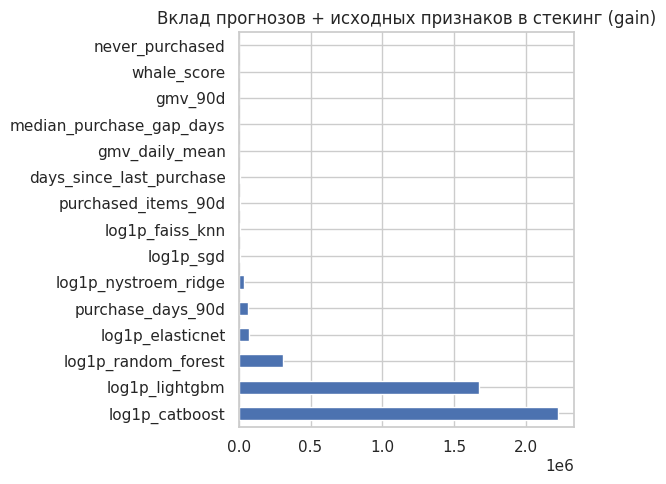

In [19]:
if best_meta_name == "meta_elasticnet_ridge":
    weights = pd.Series(final_meta_model.coef_, index=MODEL_NAMES).sort_values(ascending=False)
    print("веса базовых моделей (ElasticNet/Ridge, на log1p-предсказаниях):")
    print(weights)
    print("intercept:", final_meta_model.intercept_)

    weights.plot.barh(figsize=(6, 4))
    plt.title("Вклад базовых моделей в стекинг")
    plt.tight_layout()
    plt.show()
elif best_meta_name == "meta_lightgbm":
    importance = pd.Series(
        final_meta_model.booster_.feature_importance(importance_type="gain"), index=MODEL_NAMES
    ).sort_values(ascending=False)
    print("gain-importance базовых моделей в мета-LightGBM:")
    print(importance)

    importance.plot.barh(figsize=(6, 4))
    plt.title("Вклад базовых моделей в стекинг (gain)")
    plt.tight_layout()
    plt.show()
elif best_meta_name == "meta_lightgbm_extended":
    importance = pd.Series(
        final_meta_model.booster_.feature_importance(importance_type="gain"), index=EXTENDED_META_FEATURES
    ).sort_values(ascending=False)
    print("gain-importance признаков в расширенной мета-LightGBM:")
    print(importance)

    importance.plot.barh(figsize=(6, 5))
    plt.title("Вклад прогнозов + исходных признаков в стекинг (gain)")
    plt.tight_layout()
    plt.show()
else:
    print("используется uniform log-blend без обученной мета-модели")

**Анализ.** Gain почти целиком уходит в `log1p_catboost` и `log1p_lightgbm`
(на порядок больше остальных), с небольшой добавкой от `log1p_random_forest`
и `log1p_elasticnet`. Все 8 добавленных исходных признаков (`whale_score`,
`never_purchased`, `gmv_90d`, recency/frequency-признаки) практически не
используются — gain у них очень маленький. Это ставит под сомнение исходную
гипотезу из "расширенного стекинга".

## Сегментный разбор: помогает ли стекинг именно там, где ошибались базовые модели

Те же сегменты, что и в анализе ошибок 10_Base_Models.ipynb
(`never_purchased`, `regular`, `whale_top5pct` — топ-5% по `whale_score`).
Сравниваем лучшую одиночную модель, uniform-блендинг и финальный стекинг.

In [20]:
def segment_rmsle_table(preds_dict, y_true, segment):
    rows = {}
    for seg in ["never_purchased", "regular", "whale_top5pct"]:
        mask = (segment == seg).to_numpy()
        rows[seg] = {name: rmsle(y_true[mask], preds[mask]) for name, preds in preds_dict.items()}
    return pd.DataFrame(rows).T


holdout_segment = pd.Series("regular", index=holdout_raw.index)
holdout_segment.loc[holdout_raw["never_purchased"] == 1] = "never_purchased"
whale_p95 = holdout_raw["whale_score"].quantile(0.95)
holdout_segment.loc[holdout_raw["whale_score"] >= whale_p95] = "whale_top5pct"
holdout_segment = holdout_segment.reindex(holdout_table.index)

preds_to_compare = {
    f"best_single ({base_rmsle.index[0]})": holdout_table[base_rmsle.index[0]].to_numpy(),
    "uniform_blend": uniform_pred.to_numpy(),
    "stacking (final)": holdout_meta_preds,
}

segment_compare = segment_rmsle_table(preds_to_compare, holdout_table["y_true"].to_numpy(), holdout_segment)
segment_compare

,best_single (lightgbm),uniform_blend,stacking (final)
never_purchased,1.027980,1.031084,1.022220
regular,1.779918,1.785384,1.760148
whale_top5pct,1.533528,1.549844,1.515158


**Анализ.** Стекинг обходит лучшую одиночную модель на всех трёх сегментах,
сильнее всего на `regular` (1.780 → 1.760, −1.1%) и `whale_top5pct`
(1.534 → 1.515, −1.2%). На `never_purchased` выигрыш минимальный (сегмент и так
почти решён — таргет всегда 0).

 Важная оговорка: колонка "stacking (final)"
здесь — те самые in-sample предсказания (модель дообучена на всём holdout и
оценена на нём же), а не честная OOF-оценка; результат стоит перепроверить используя честную OOF оценку стекинга

## Сабмит на inference cutoff

In [21]:
if best_meta_name == "meta_lightgbm_extended":
    X_meta_inference = meta_inference_ext[EXTENDED_META_FEATURES].to_numpy()
else:
    X_meta_inference = meta_inference[META_FEATURES].to_numpy()

if final_meta_model is not None:
    inference_meta_preds = np.clip(np.expm1(final_meta_model.predict(X_meta_inference)), 0, None)
else:
    inference_meta_preds = blend_log(inference_table, MODEL_NAMES, uniform_weights).to_numpy()

stacked_submission = pd.DataFrame({"user_id": inference_table.index, "predict": inference_meta_preds})
stacked_submission["predict"] = stacked_submission["predict"].clip(lower=0)

assert len(stacked_submission) == len(inference_table)
assert stacked_submission["predict"].ge(0).all()

stacked_path = SUBMISSIONS_DIR / "stacking_meta_model.csv"
stacked_submission.to_csv(stacked_path, index=False)

print("сохранено:", stacked_path)
stacked_submission.head()

сохранено: /home/jupyter/project/submissions/stacking_meta_model.csv


,user_id,predict
0,2,1.547087
1,7,69.010487
2,15,5.353162
3,18,113.700055
4,23,0.452785


Переименовал stacking_meta_model.csv --> stacking_meta_lightgbm.csv

## Альтернативный сабмит: мета ElasticNet

In [6]:
final_elasticnet_model = ElasticNet(**study_meta_en.best_params, positive=True, max_iter=5000, random_state=RANDOM_STATE)
final_elasticnet_model.fit(X_meta_holdout, y_meta_holdout_log)

elasticnet_holdout_preds = np.clip(np.expm1(final_elasticnet_model.predict(X_meta_holdout)), 0, None)
elasticnet_holdout_rmsle = rmsle(holdout_table["y_true"], elasticnet_holdout_preds)
print(f"ElasticNet meta-стекинг, in-sample holdout RMSLE: {elasticnet_holdout_rmsle:.5f}")

X_meta_inference_en = meta_inference[META_FEATURES].to_numpy()
elasticnet_inference_preds = np.clip(np.expm1(final_elasticnet_model.predict(X_meta_inference_en)), 0, None)

elasticnet_submission = pd.DataFrame({"user_id": inference_table.index, "predict": elasticnet_inference_preds})
elasticnet_submission["predict"] = elasticnet_submission["predict"].clip(lower=0)

assert len(elasticnet_submission) == len(inference_table)
assert elasticnet_submission["predict"].ge(0).all()

elasticnet_path = SUBMISSIONS_DIR / "stacking_meta_elasticnet.csv"
elasticnet_submission.to_csv(elasticnet_path, index=False)

print("сохранено:", elasticnet_path)
elasticnet_submission.head()

ElasticNet meta-стекинг, in-sample holdout RMSLE: 1.67038
сохранено: /home/jupyter/project/submissions/stacking_meta_elasticnet.csv


,user_id,predict
0,2,1.319399
1,7,63.721284
2,15,6.765563
3,18,112.430718
4,23,0.310080


## Итог

| Вариант | RMSLE |
|---|---|
| лучшая одиночная базовая модель (LightGBM) | 1.6854 (holdout rmlse) |
| uniform / inverse-RMSLE log blend | 1.6911 / 1.6910 (holdout rmlse) |
| мета-модель на 7 прогнозах (ElasticNet / LightGBM) | 1.6704 / 1.6701 (5-fold CV на holdout) |
| мета-модель на 7 прогнозах + исходных признаках (LightGBM)| 1.6696 (5-fold CV на holdout) |

Стекинг выигрывает у лучшей одиночной модели и у блендинга (~0.015
RMSLE, ~0.9%), но выигрыш почти целиком получается уже от простого линейного
взвешивания 7 прогнозов — усложнение (нелинейный LightGBM, затем ещё и
исходные признаки) добавляет на порядок меньше.

## Результаты сабмитов (вышло хуже, чем ожидалось)

| Файл | Описание | Public RMSLE |
|---|---|---|
| base_lightgbm.csv | лучшая одиночная базовая модель (LightGBM) | 1,6593651677462053 |
| stacking_meta_elasticnet.csv | мета-модель ElasticNet на 7 прогнозах | 1,657995788908437 |
| stacking_meta_lightgbm.csv | мета-модель LightGBM на 7 прогнозах + исходных признаках | 1,6588914845065432 |

Прирост от объединения прогнозов на Public RMSLE совсем незначителен.

В дальнейшем нужно искать модели, прогнозы которых будут отличаться значительно сильнее того, что было использовано здесь.